Prepare data

In [7]:
import pandas as pd

# the csv has ~250 inflection columns; only the lemma is needed here
nouns = pd.read_csv("nouns.csv", low_memory=False, usecols=["lemma"])

# keep plain letter words (a-z plus äöüß), lowercased and deduplicated.
# .lower() rather than .casefold(): casefold turns "ß" into "ss" and would
# change word lengths.
lemma = nouns["lemma"].astype(str)
lemma = lemma[lemma.str.fullmatch(r"[A-Za-zÄÖÜäöüß]+")].str.lower()

nouns = pd.DataFrame({"lemma": sorted(set(lemma))})
nouns["length"] = nouns["lemma"].str.len()
print(len(nouns), "nouns, lengths", nouns["length"].min(), "-", nouns["length"].max())
nouns.head()

95031 nouns, lengths 1 - 85


,lemma,length
0,a,1
1,aa,2
2,aab,3
3,aach,4
4,aachen,6


In [8]:
# bucket the nouns by length: lennouns[n] holds every noun of length n,
# so the list index *is* the word length (lennouns[0] is empty on purpose)
lennouns = [nouns[nouns["length"] == n] for n in range(nouns["length"].max() + 1)]

print(len(lennouns), "buckets;", sum(len(df) for df in lennouns), "nouns")
lennouns[5].head()

86 buckets; 95031 nouns


,lemma,length
10,aaken,5
25,aalen,5
58,aalst,5
72,aarau,5
79,aaron,5


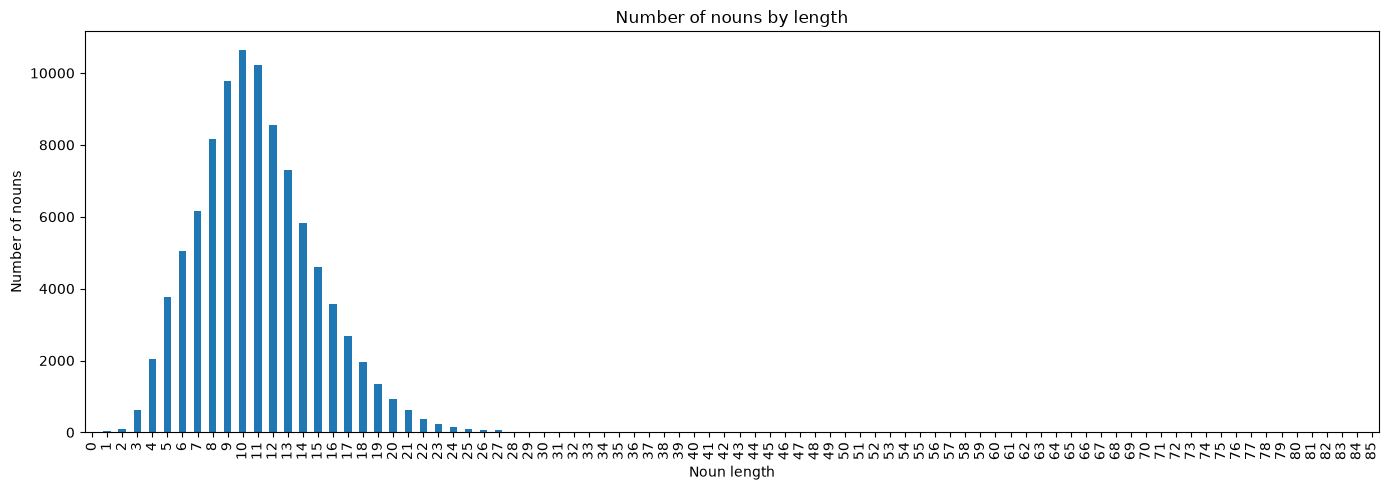

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

counts = pd.Series([len(df) for df in lennouns], index=range(len(lennouns)))

counts.plot(kind="bar", figsize=(14, 5))
plt.xlabel("Noun length")
plt.ylabel("Number of nouns")
plt.title("Number of nouns by length")
plt.tight_layout()
plt.show()

## Hangman


`GameState` fields:

| field | meaning |
|---|---|
| `pattern` | e.g. `"h_ll_"`, `"_"` for unknown positions |
| `guessed` / `correct` / `wrong` | frozensets of letters tried / hit / missed |
| `lives_left`, `max_wrong` | wrong guesses remaining / allowed |
| `alphabet` | 30 letters: `a-z` plus `äöüß` |
| `candidates` | **every** word of this length, unfiltered |

Helpers: `state.unguessed` (letters not yet tried), `state.matches(word)` (is a
word still consistent with the board?), `state.consistent_candidates()`
(`candidates` run through `matches`).

Returning an illegal guess (not a letter, not in the alphabet, already tried)
raises `StrategyError` rather than silently costing a life.

In [10]:
%load_ext autoreload
%autoreload 2

import hangman
from hangman import GameState, play, evaluate, compare, sample_words

words = hangman.load_words()   # {length: (word, ...)}, cached
print(sum(len(v) for v in words.values()), "words")

# baseline: fixed frequency order, ignores the board
print(evaluate(hangman.frequency_strategy, words, n_games=500, seed=0))

95031 words
1128/10585 won (10.7%)  avg guesses 12.90  avg wrong 5.78  avg misses 10.55


In [11]:
def my_strategy(state: GameState) -> str:
    """Your strategy: pick the next letter to guess from `state`."""
    return state.unguessed[0]


# one game, move by move
play("hangman" if 7 in words else words[min(words)][0], my_strategy, words, verbose=True)

  a hit   _a___a_  lives 6
  b miss  _a___a_  lives 5
  c miss  _a___a_  lives 4
  d miss  _a___a_  lives 3
  e miss  _a___a_  lives 2
  f miss  _a___a_  lives 1
  g hit   _a_g_a_  lives 1
  h hit   ha_g_a_  lives 1
  i miss  ha_g_a_  lives 0  (played out)
  j miss  ha_g_a_  lives 0  (played out)
  k miss  ha_g_a_  lives 0  (played out)
  l miss  ha_g_a_  lives 0  (played out)
  m hit   ha_gma_  lives 0  (played out)
  n hit   hangman  lives 0  (played out)


GameResult(word='hangman', won=False, guesses=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n'], wrong=['b', 'c', 'd', 'e', 'f', 'i', 'j', 'k', 'l'], patterns=['_a___a_', '_a___a_', '_a___a_', '_a___a_', '_a___a_', '_a___a_', '_a_g_a_', 'ha_g_a_', 'ha_g_a_', 'ha_g_a_', 'ha_g_a_', 'ha_g_a_', 'ha_gma_', 'hangman'], max_wrong=6, stopped_at=9)

In [17]:
def dumb_strategy(state: GameState) -> str:
    """A dumb strategy: just pick the first unguessed letter."""

    return state.unguessed[0]
def freq_strategy(state: GameState) -> str:
    """Picking the next letter to guess from `state` based on a fixed frequency order."""
    distrib = ['e', 'r', 'n', 'a', 'i', 't', 's', 'l', 'h', 'u', 'o', 'g', 'c', 'm', 'k', 'b', 'd', 'f', 'p', 'z', 'w', 'v', 'ä', 'ü', 'y', 'ö', 'j', 'ß', 'x', 'q']
    distrib = [i for i in distrib if i not in state.guessed]
    return distrib[0]

def letter_frequency_strategy(state: GameState) -> str:
    remaining = state.consistent_candidates()
    if not remaining:
        return state.unguessed[0]
    counts = pd.Series([c for w in remaining for c in set(w)]).value_counts()
    counts = counts[counts.index.isin(state.unguessed)]
    return counts.idxmax() if not counts.empty else state.unguessed[0]


In [27]:
n = 500

# same seed => same words, so strategies are compared on identical games
stats_dumb = evaluate(dumb_strategy, words, n_games=n, seed=0, max_wrong=6)
print(stats_dumb)

stats_freq = evaluate(freq_strategy, words, n_games=n, seed=0, max_wrong=6)
print(stats_freq)

stats_letter_freq = evaluate(letter_frequency_strategy, words, n_games=n, seed=0, max_wrong=6)
print(stats_letter_freq)

stats = [stats_dumb, stats_freq, stats_letter_freq]



58/10585 won (0.5%)  avg guesses 10.23  avg wrong 5.99  avg misses 13.32
1141/10585 won (10.8%)  avg guesses 12.90  avg wrong 5.78  avg misses 10.54
9976/10585 won (94.2%)  avg guesses 10.20  avg wrong 1.14  avg misses 1.23


In [50]:
from random import sample

from itertools import groupby

by_len = lambda r: len(r.word)
for length, group in groupby(sorted(stats_letter_freq.losses(), key=by_len), key=by_len):
    for r in list(group)[:5]:
        print("Len", str(length) + ":", str(r)[5:])


# compare({"frequency": hangman.frequency_strategy, "mine": letter_frequency_strategy},
#         words=words, n_games=500, seed=0)

Len 3: 'gäa' in 8 guesses (6 wrong: eoinbd, 6 to finish)
Len 3: 'sou' in 8 guesses (6 wrong: aebndg, 7 to finish)
Len 3: 'rtl' in 6 guesses (6 wrong: aeouid, 7 to finish)
Len 3: 'ivf' in 7 guesses (6 wrong: aeouhl, 8 to finish)
Len 3: 'ria' in 8 guesses (6 wrong: eocdfm, 7 to finish)
Len 4: 'tipp' in 8 guesses (6 wrong: aeonkl, 7 to finish)
Len 4: 'crow' in 8 guesses (6 wrong: aelgbf, 6 to finish)
Len 4: 'smog' in 8 guesses (6 wrong: aelrnh, 6 to finish)
Len 4: 'chef' in 7 guesses (6 wrong: aiorln, 6 to finish)
Len 4: 'zaya' in 7 guesses (6 wrong: mrgnpv, 7 to finish)
Len 5: 'füdle' in 9 guesses (6 wrong: aiuoth, 6 to finish)
Len 5: 'wippe' in 8 guesses (6 wrong: anlktr, 8 to finish)
Len 5: 'ziege' in 9 guesses (6 wrong: smflrw, 6 to finish)
Len 5: 'haxen' in 10 guesses (6 wrong: rlmgbf, 7 to finish)
Len 5: 'debüt' in 8 guesses (6 wrong: aiourh, 6 to finish)
Len 6: 'tauber' in 9 guesses (6 wrong: lnskgp, 6 to finish)
Len 6: 'medium' in 7 guesses (6 wrong: nrlstg, 6 to finish)
Len 6: 'f

In [29]:
names = ["Dumb", "Frequency", "Letter counting"]

# letters in the lost words, each counted once per word it appears in.
# "all words" is the same measure over the whole list, to compare against.
loss_letters = pd.DataFrame({n: s.loss_letter_freq for n, s in zip(names, stats)})
loss_letters["all words"] = pd.Series(
    hangman.letter_frequency((w for ws in words.values() for w in ws), by_word=True))
# a letter missing from a strategy's losses occurs there zero times, not NaN
loss_letters = loss_letters.fillna(0).sort_values("all words", ascending=False)

# how the lost words spread over word length (raw counts -- short buckets get
# fewer games than they ask for, so compare against by_length.win_rate too)
loss_lengths = pd.DataFrame({n: s.loss_lengths for n, s in zip(names, stats)}).fillna(0).astype(int)

display(loss_letters.head(15))
display(loss_lengths.head(20))

,Dumb,Frequency,Letter counting,all words
e,0.087539,0.087685,0.085612,0.095106
r,0.071881,0.071473,0.054236,0.076037
n,0.070536,0.069105,0.034065,0.070590
a,0.064951,0.064205,0.079337,0.068432
i,0.066472,0.065025,0.059615,0.066534
t,0.065996,0.064310,0.052443,0.065369
s,0.067402,0.065787,0.046168,0.064298
l,0.050772,0.049938,0.041237,0.053396
h,0.049003,0.047395,0.042582,0.047389
u,0.047876,0.046398,0.058270,0.045159


,Dumb,Frequency,Letter counting
length,,,
3,477,456,282
4,490,456,176
5,498,462,109
6,498,464,35
7,499,474,6
8,500,471,1
9,499,473,0
10,499,472,0
11,500,470,0


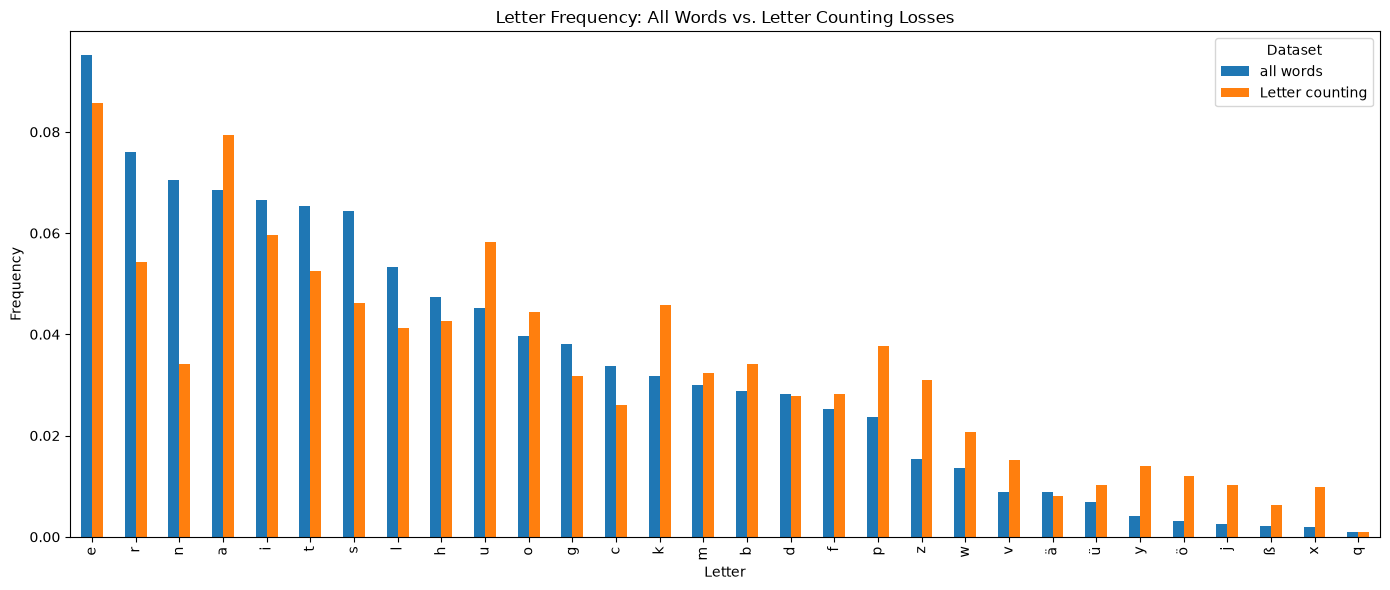

In [33]:
loss_letters[["all words", "Letter counting"]].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("Letter")
plt.ylabel("Frequency")
plt.title("Letter Frequency: All Words vs. Letter Counting Losses")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

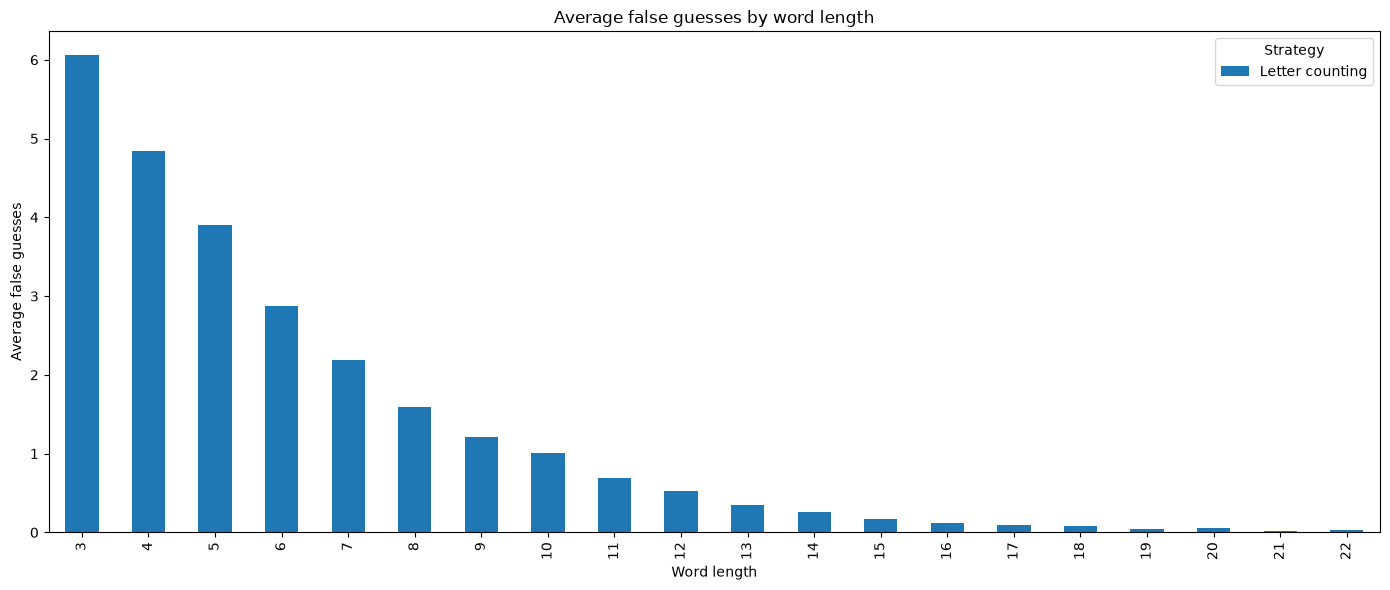

In [30]:
avg_guesses = pd.DataFrame({
    # "Dumb": stats[0].by_length.avg_misses,
    # "Frequency": stats[1].by_length.avg_misses,
    "Letter counting": stats[2].by_length.avg_misses[:20],
})

avg_guesses.plot(kind="bar", figsize=(14, 6))

plt.xlabel("Word length")
plt.ylabel("Average false guesses")
plt.title("Average false guesses by word length")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()

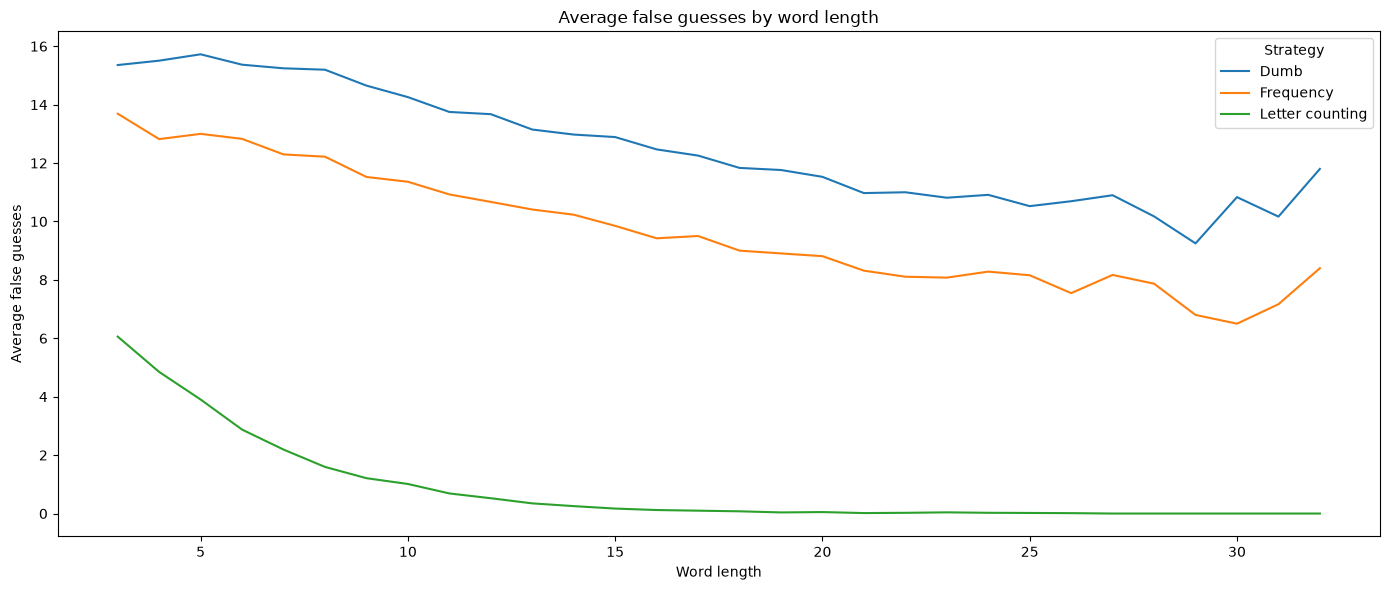

In [31]:

avg_guesses = pd.DataFrame({
    "Dumb": stats[0].by_length.avg_misses[:30],
    "Frequency": stats[1].by_length.avg_misses[:30],
    "Letter counting": stats[2].by_length.avg_misses[:30]
})

avg_guesses.plot(kind="line", figsize=(14, 6))
plt.xlabel("Word length")
plt.ylabel("Average false guesses")
plt.title("Average false guesses by word length")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()

In [32]:
stats[2].by_length.avg_misses[:30]


length
3     6.058000
4     4.848000
5     3.904000
6     2.874000
7     2.190000
8     1.596000
9     1.210000
10    1.012000
11    0.688000
12    0.524000
13    0.348000
14    0.254000
15    0.170000
16    0.120000
17    0.098000
18    0.076000
19    0.038000
20    0.050000
21    0.016000
22    0.024457
23    0.040650
24    0.025157
25    0.019802
26    0.013333
27    0.000000
28    0.000000
29    0.000000
30    0.000000
31    0.000000
32    0.000000
Name: avg_misses, dtype: float64